# Predicting Football Player Market Value Using Machine Learning

## An Analysis of EA SPORTS FC 24 Player Data

### Author
Viola Kulabako

### Project Objective

The objective of this project is to develop machine learning models capable of predicting a football player's market value using demographic, physical, technical, and performance-related attributes from the EA SPORTS FC 24 player dataset.

The project applies Exploratory Data Analysis (EDA), feature engineering, and three regression models—Linear Regression, Polynomial Regression, and Ridge Regression to determine which approach best predicts player market values. I have evaluated model performance using Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and the coefficient of determination (R²).

The findings may provide useful insights for football clubs, scouts, analysts, and decision-makers involved in player recruitment and valuation.

# About the Dataset

This project uses the EA SPORTS FC 24 Complete Player Dataset obtained from Kaggle.

The dataset contains information on over 19,000 professional football (soccer) players from different leagues around the world. Each player record includes demographic information, physical characteristics, technical abilities, market value, wages, club affiliation, nationality, and performance ratings.

### Target Variable

- value_eur (Player Market Value)

### Example Predictor Variables

- age
- overall
- potential
- wage_eur
- pace
- shooting
- passing
- dribbling
- defending
- physic
- international_reputation
- skill_moves
- weak_foot
- height_cm
- weight_kg

Dataset Source:
https://www.kaggle.com/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset

In [1]:
# Import data manipulation libraries
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

# Notebook settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv("male_players.csv")

# Display the first five rows
df.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_22768\2481205868.py:2: DtypeWarning: Columns (108) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("male_players.csv")


,player_id,player_url,fifa_version,fifa_update,update_as_of,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,dob,height_cm,weight_kg,club_team_id,club_name,league_id,league_name,league_level,club_position,club_jersey_number,club_loaned_from,club_joined_date,club_contract_valid_until_year,nationality_id,nationality_name,nation_team_id,nation_position,nation_jersey_number,preferred_foot,weak_foot,skill_moves,international_reputation,work_rate,body_type,real_face,release_clause_eur,player_tags,player_traits,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk
0,231747,/player/231747/kylian-mbappe/240002,24.0,2.0,2023-09-22,K. Mbappé,Kylian Mbappé Lottin,"ST, LW",91,94,181500000.0,230000.0,24,1998-12-20,182,75,73.0,Paris Saint Germain,16.0,Ligue 1,1.0,LW,7.0,NaN,2018-07-01,2024.0,18,France,1335.0,LW,10.0,Right,4,5,5,High/Low,Unique,Yes,349400000.0,"#Speedster, #Dribbler, #Acrobat, #Clinical fin...","Quick Step +, Rapid, Flair, Trivela",97.0,90.0,80.0,92.0,36.0,78.0,78,94,73,86,84,93,80,69,71,92,97,97,93,93,82,90,88,88,77,83,64,38,93,83,84,88.0,26,34,32,13,5,7,11,6,NaN,90+3,90+3,90+3,91,91,91,91,91,89+3,89+3,89+3,89+3,81+3,81+3,81+3,89+3,68+3,63+3,63+3,63+3,68+3,63+3,54+3,54+3,54+3,63+3,18+3
1,239085,/player/239085/erling-haaland/240002,24.0,2.0,2023-09-22,E. Haaland,Erling Braut Haaland,ST,91,94,185000000.0,340000.0,22,2000-07-21,195,94,10.0,Manchester City,13.0,Premier League,1.0,ST,9.0,NaN,2022-07-01,2027.0,36,Norway,1352.0,ST,9.0,Left,3,3,5,High/Medium,Unique,Yes,356100000.0,"#Aerial threat, #Distance shooter, #Strength, ...","Acrobatic +, Power Header, Quick Step",89.0,93.0,66.0,80.0,45.0,88.0,47,96,83,77,90,79,77,62,53,82,82,94,76,94,72,94,93,76,93,86,87,43,96,74,84,87.0,38,47,29,7,14,13,11,7,NaN,90+3,90+3,90+3,82,86,86,86,82,82+3,82+3,82+3,79+3,74+3,74+3,74+3,79+3,62+3,63+3,63+3,63+3,62+3,60+3,62+3,62+3,62+3,60+3,19+3
2,192985,/player/192985/kevin-de-bruyne/240002,24.0,2.0,2023-09-22,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,103000000.0,350000.0,32,1991-06-28,181,75,10.0,Manchester City,13.0,Premier League,1.0,SUB,17.0,NaN,2015-08-30,2025.0,7,Belgium,1325.0,CAM,7.0,Right,5,4,5,High/Medium,Unique,Yes,190600000.0,"#Dribbler, #Playmaker, #Distance shooter, #Cro...","Pinged Pass +, Dead Ball, Incisive Pass, Long ...",72.0,88.0,94.0,87.0,65.0,78.0,95,85,55,94,83,86,92,83,94,92,72,72,74,92,78,92,72,88,74,92,75,66,88,95,83,88.0,66,70,53,15,13,5,10,13,NaN,83+3,83+3,83+3,87,88,88,88,87,89+2,89+2,89+2,88+3,90+1,90+1,90+1,88+3,79+3,80+3,80+3,80+3,79+3,75+3,70+3,70+3,70+3,75+3,21+3
3,158023,/player/158023/lionel-messi/240002,24.0,2.0,2023-09-22,L. Messi,Lionel Andrés Messi Cuccittini,"CF, CAM",90,90,41000000.0,23000.0,36,1987-06-24,169,67,112893.0,Inter Miami,39.0,Major League Soccer,1.0,RF,10.0,NaN,2023-07-16,2025.0,52,Argentina,1369.0,RW,10.0,Left,4,4,5,Low/Low,Unique,Yes,61500000.0,"#Dribbler, #Playmaker, #FK Specialist, #Acroba...","Technical +, Finesse Shot, Dead Ball, Pinged P...",80.0,87.0,90.0,94.0,33.0,64.0,83,89,60,91,86,96,93,93,90,93,87,74,91,88,95,83,71,70,68,90,44,40,91,92,75,96.0,20,35,24,6,11,15,14,8,NaN,85+3,85+3,85+3,90,89,89,89,90,91-1,91-1,91-1,89+1,85+3,85+3,85+3,89+1,64+3,63+3,63+3,63+3,64+3,59+3,49+3,49+3,49+3,59+3,

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (180021, 109)

Column Names:
['player_id', 'player_url', 'fifa_version', 'fifa_update', 'update_as_of', 'short_name', 'long_name', 'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur', 'age', 'dob', 'height_cm', 'weight_kg', 'club_team_id', 'club_name', 'league_id', 'league_name', 'league_level', 'club_position', 'club_jersey_number', 'club_loaned_from', 'club_joined_date', 'club_contract_valid_until_year', 'nationality_id', 'nationality_name', 'nation_team_id', 'nation_position', 'nation_jersey_number', 'preferred_foot', 'weak_foot', 'skill_moves', 'international_reputation', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'player_traits', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'mov

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180021 entries, 0 to 180020
Columns: 109 entries, player_id to gk
dtypes: float64(20), int64(43), object(46)
memory usage: 149.7+ MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
player_id,180021.0,217326.670294,35215.749284,2.0,200759.0,222734.0,239858.0,278145.0
fifa_version,180021.0,19.621450,2.838621,15.0,17.0,20.0,22.0,24.0
fifa_update,180021.0,2.000000,0.000000,2.0,2.0,2.0,2.0,2.0
overall,180021.0,65.712711,7.018104,40.0,61.0,66.0,70.0,94.0
potential,180021.0,70.779581,6.255569,40.0,66.0,71.0,75.0,95.0
...,...,...,...,...,...,...,...,...
goalkeeping_handling,180021.0,16.260136,16.846583,1.0,8.0,11.0,14.0,92.0
goalkeeping_kicking,180021.0,16.129902,16.499513,1.0,8.0,11.0,14.0,95.0
goalkeeping_positioning,180021.0,16.276951,17.009393,1.0,8.0,11.0,14.0,92.0
goalkeeping_reflexes,180021.0,16.615517,17.971201,1.0,8.0,11.0,14.0,94.0


## Initial Observations

After loading the dataset, the first step is to inspect its structure and quality. The dataset contains player information, including demographic characteristics, technical attributes, physical measurements, and financial information.

The `info()` function provides an overview of the available variables, their data types, and the presence of missing values, while `describe()` summarizes the distribution of numerical features. These observations will guide the subsequent data cleaning and exploratory data analysis stages.

# Data Cleaning and Preprocessing

Before building machine learning models, it is important to examine the quality of the dataset. Real-world datasets often contain missing values, duplicate records, inconsistent data types, or irrelevant variables that can negatively affect model performance.

In this section, the dataset will be inspected and cleaned to ensure it is suitable for exploratory data analysis and predictive modeling.

In [6]:
# Check missing values

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

missing_values

nation_position                   169923
nation_jersey_number              169923
nation_team_id                    169923
club_loaned_from                  169298
player_tags                       166103
goalkeeping_speed                 159997
player_traits                      98216
release_clause_eur                 59299
mentality_composure                32888
physic                             20024
defending                          20024
dribbling                          20024
passing                            20024
shooting                           20024
pace                               20024
club_joined_date                   12588
league_level                        2250
value_eur                           2153
club_position                       1865
club_name                           1865
league_id                           1865
club_contract_valid_until_year      1865
league_name                         1865
club_jersey_number                  1865
club_team_id    

In [7]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

missing_percentage

nation_position                   94.390654
nation_jersey_number              94.390654
nation_team_id                    94.390654
club_loaned_from                  94.043473
player_tags                       92.268680
goalkeeping_speed                 88.876853
player_traits                     54.558079
release_clause_eur                32.940046
mentality_composure               18.268980
physic                            11.123147
defending                         11.123147
dribbling                         11.123147
passing                           11.123147
shooting                          11.123147
pace                              11.123147
club_joined_date                   6.992518
league_level                       1.249854
value_eur                          1.195972
club_position                      1.035990
club_name                          1.035990
league_id                          1.035990
club_contract_valid_until_year     1.035990
league_name                     

In [8]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


 Since no duplicates were found we proceed to the next stage, most large datasets have a tendency to have duplicates, if we had duplicates, we would proceed to drop them.

In [9]:
df.dtypes.value_counts()

object     46
int64      43
float64    20
Name: count, dtype: int64

In [10]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

categorical_columns = df.select_dtypes(include=['object']).columns

print("Number of Numerical Features:", len(numeric_columns))
print("Number of Categorical Features:", len(categorical_columns))

Number of Numerical Features: 63
Number of Categorical Features: 46


In [11]:
selected_columns = [
    'value_eur',
    'overall',
    'potential',
    'age',
    'wage_eur',
    'height_cm',
    'weight_kg',
    'pace',
    'shooting',
    'passing',
    'dribbling',
    'defending',
    'physic',
    'international_reputation',
    'skill_moves',
    'weak_foot'
]

players = df[selected_columns]

players.head()

,value_eur,overall,potential,age,wage_eur,height_cm,weight_kg,pace,shooting,passing,dribbling,defending,physic,international_reputation,skill_moves,weak_foot
0,181500000.0,91,94,24,230000.0,182,75,97.0,90.0,80.0,92.0,36.0,78.0,5,5,4
1,185000000.0,91,94,22,340000.0,195,94,89.0,93.0,66.0,80.0,45.0,88.0,5,3,3
2,103000000.0,91,91,32,350000.0,181,75,72.0,88.0,94.0,87.0,65.0,78.0,5,4,5
3,41000000.0,90,90,36,23000.0,169,67,80.0,87.0,90.0,94.0,33.0,64.0,5,4,4
4,51000000.0,90,90,35,95000.0,185,81,79.0,88.0,83.0,87.0,39.0,78.0,5,4,4


In [12]:
players.isnull().sum()

value_eur                    2153
overall                         0
potential                       0
age                             0
wage_eur                     1848
height_cm                       0
weight_kg                       0
pace                        20024
shooting                    20024
passing                     20024
dribbling                   20024
defending                   20024
physic                      20024
international_reputation        0
skill_moves                     0
weak_foot                       0
dtype: int64

In [13]:
players = players.dropna()

In [14]:
df.shape

(180021, 109)

In [15]:
print(players.shape)

(158128, 16)


### Dataset Filtering

The original dataset contains player records from multiple FIFA and EA SPORTS FC editions (FIFA 15 through EA SPORTS FC 24). Since the objective of this project is to analyze the most recent player data, the dataset is filtered to include only EA SPORTS FC 24 records (`fifa_version = 24`).

This reduces duplicate observations across different game editions and ensures that the analysis reflects current player attributes and market values.

In [16]:
df['fifa_version'].value_counts().sort_index()


fifa_version
15.0    16182
16.0    16706
17.0    17596
18.0    17954
19.0    18086
20.0    18483
21.0    18892
22.0    19239
23.0    18533
24.0    18350
Name: count, dtype: int64

In [17]:
players_df = df[df['fifa_version'] == 24].copy()

In [26]:
selected_columns = [
    'value_eur',
    'overall',
    'potential',
    'age',
    'wage_eur',
    'height_cm',
    'weight_kg',
    'pace',
    'shooting',
    'passing',
    'dribbling',
    'defending',
    'physic',
    'international_reputation',
    'skill_moves',
    'weak_foot'
]

players = df[selected_columns].dropna()

print(players.shape)

(158128, 16)


In [27]:
players_df.shape

(18350, 109)

In [28]:
# Basic information about the filtered dataset
print(f"Number of players: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

print("\nTop 10 columns:")
print(df.columns[:10].tolist())

Number of players: 180021
Number of features: 109

Top 10 columns:
['player_id', 'player_url', 'fifa_version', 'fifa_update', 'update_as_of', 'short_name', 'long_name', 'player_positions', 'overall', 'potential']


## Data Cleaning Summary

The dataset was inspected for missing values, duplicate records, and inconsistent data types. A subset of relevant features was selected based on their expected relationship with player market value.

Rows containing missing values within the selected variables were removed to ensure complete observations for model training. Duplicate records, if present, were also removed. The resulting dataset provides a clean and consistent foundation for exploratory data analysis and predictive modeling.

# Feature Selection

The selected predictor variables represent player characteristics that are expected to influence market value.

- Overall Rating reflects the player's current ability.
- Potential represents future growth.
- Wage serves as an indicator of perceived player value.
- Physical measurements (height and weight) may influence performance in certain positions.
- Technical attributes (pace, shooting, passing, dribbling, defending, and physicality) summarize a player's football abilities.
- International reputation, skill moves, and weak foot ratings provide additional measures of player quality and versatility.

These features were selected because they are both interpretable and relevant to football scouting and valuation.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is used to understand the structure and characteristics of the dataset before developing predictive models. This section explores player demographics, technical abilities, and market values to identify trends, relationships, and potential outliers.

The insights gained during EDA will help guide feature selection and model development.

### Business Question 1
What does the distribution of player market values look like?

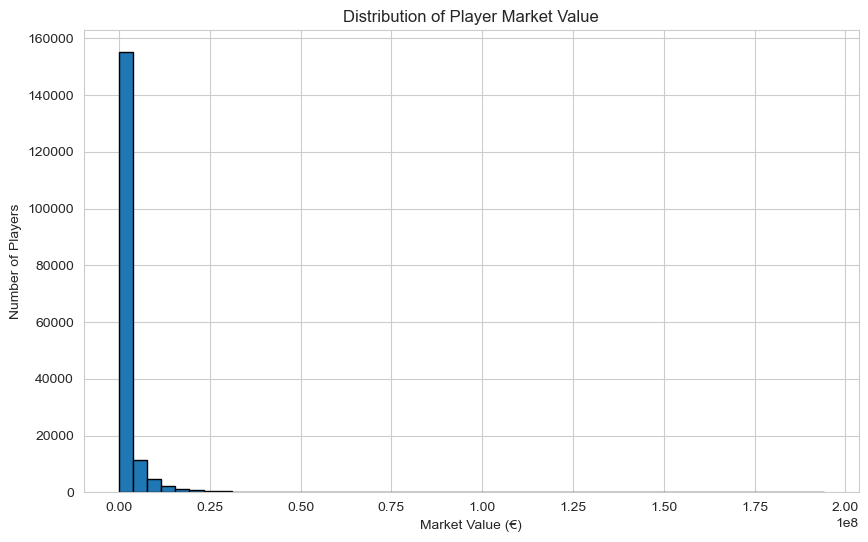

In [20]:
plt.figure(figsize=(10,6))

plt.hist(df['value_eur'], bins=50, edgecolor='black')

plt.title("Distribution of Player Market Value")
plt.xlabel("Market Value (€)")
plt.ylabel("Number of Players")

plt.show()

### Interpretation

The distribution of player market values is expected to be highly right-skewed. Most professional players have a relatively modest market value, while only a small number of elite players are held at an exceptionally high transfer value.

This suggests that player value is not evenly distributed across professional football, making it important to consider outliers during model development.

### Business Question 2
How are player ages distributed?

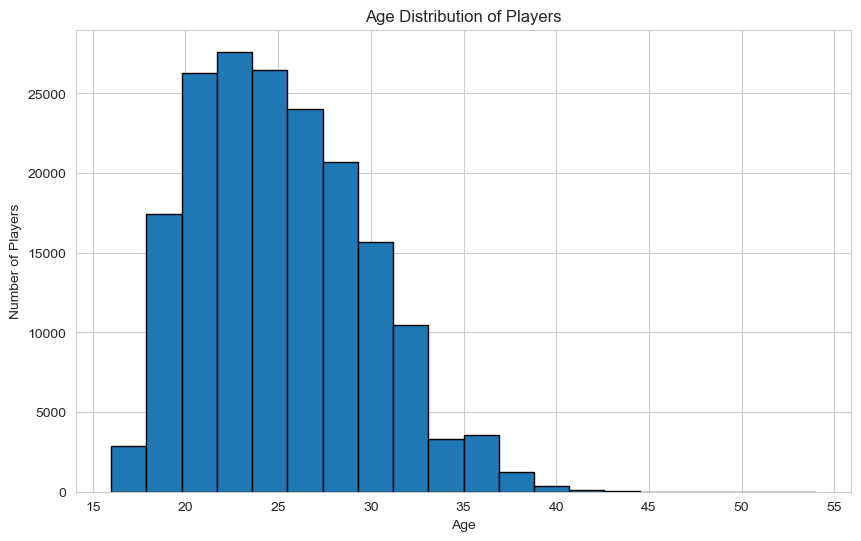

In [21]:
plt.figure(figsize=(10,6))

plt.hist(df['age'], bins=20, edgecolor='black')

plt.title("Age Distribution of Players")
plt.xlabel("Age")
plt.ylabel("Number of Players")

plt.show()

### Interpretation

The histogram shows the age distribution of players in EA SPORTS FC 24. It helps identify the most common age range represented in the dataset and provides insight into the balance between young prospects and experienced professionals.

### Business Question 3
What is the distribution of overall player ratings?

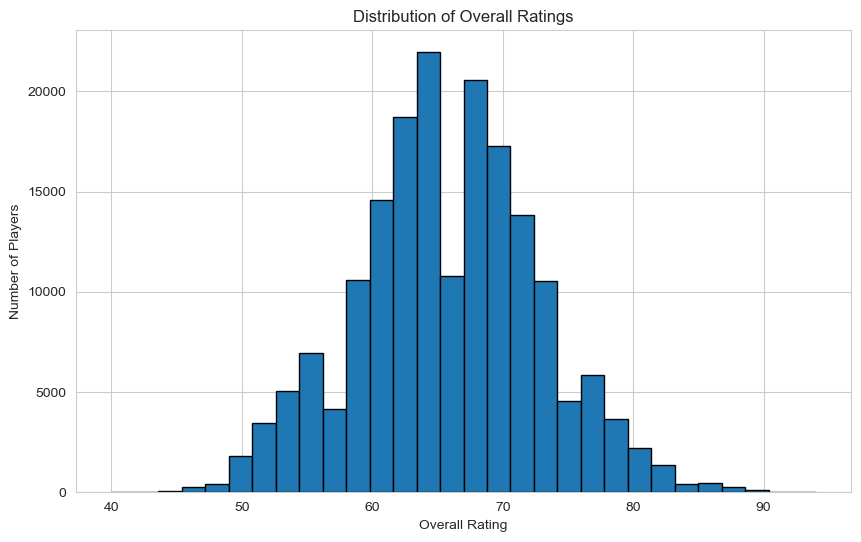

In [22]:
plt.figure(figsize=(10,6))

plt.hist(df['overall'], bins=30, edgecolor='black')

plt.title("Distribution of Overall Ratings")
plt.xlabel("Overall Rating")
plt.ylabel("Number of Players")

plt.show()

### Interpretation

Overall ratings summarize a player's current ability. Understanding their distribution helps determine whether the dataset contains mostly average players or a larger proportion of elite footballers.

### Business Question 4
Does overall rating influence market value?

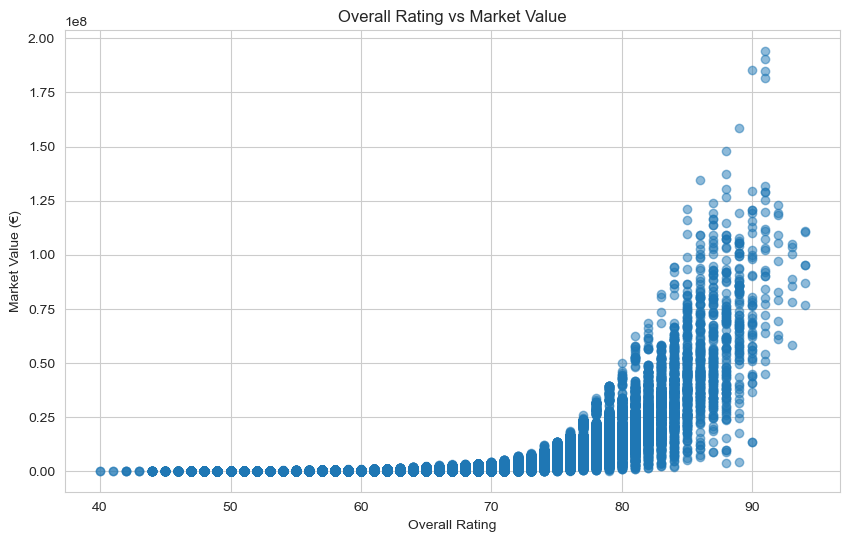

In [23]:
plt.figure(figsize=(10,6))

plt.scatter(df['overall'], df['value_eur'], alpha=0.5)

plt.title("Overall Rating vs Market Value")

plt.xlabel("Overall Rating")

plt.ylabel("Market Value (€)")

plt.show()

### Interpretation

This scatter plot investigates whether higher-rated players tend to have higher market values. A positive trend would suggest that overall ability is an important factor in determining player valuation.

### Business Question 5
Does a player's potential influence market value?

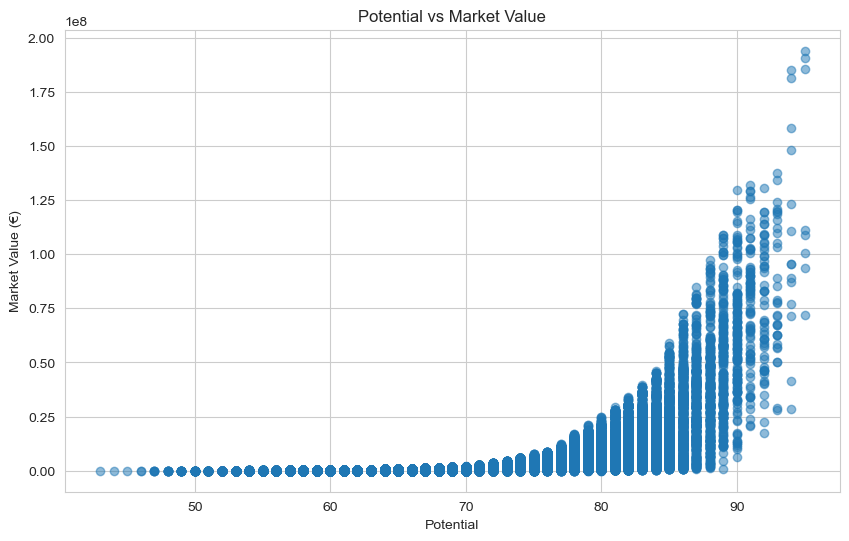

In [24]:
plt.figure(figsize=(10,6))

plt.scatter(df['potential'], df['value_eur'], alpha=0.5)

plt.title("Potential vs Market Value")

plt.xlabel("Potential")

plt.ylabel("Market Value (€)")

plt.show()

### Interpretation

Potential represents a player's future development. Players with higher potential are generally expected to command greater market values because clubs invest in long-term talent.

### Business Question 6
Which variables are most correlated with market value?

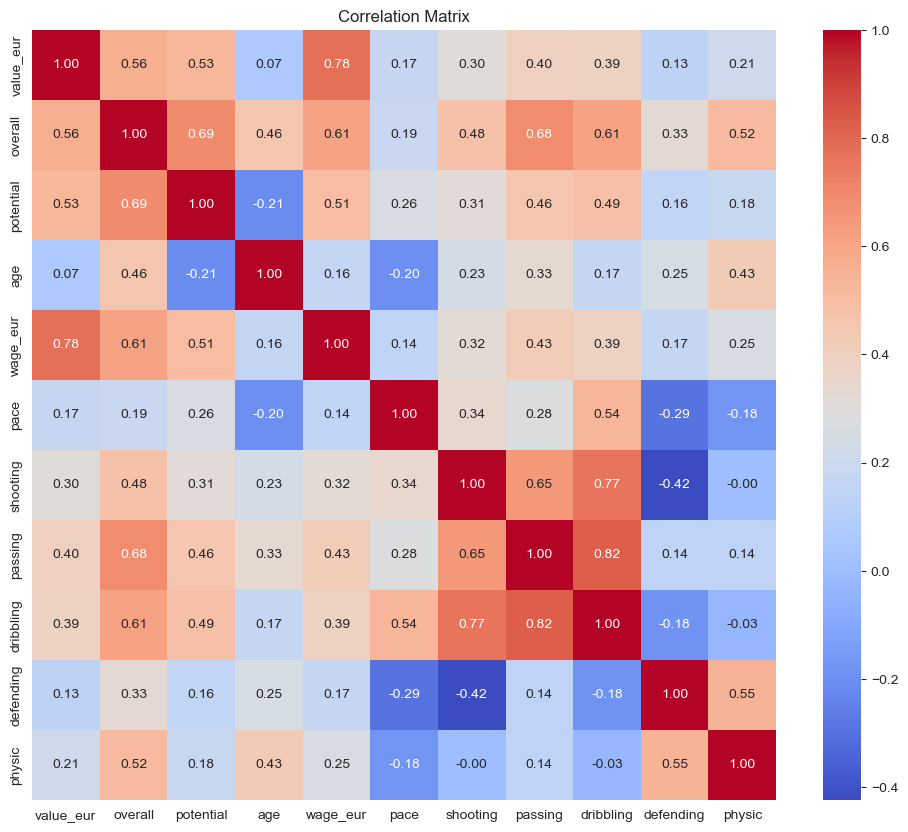

In [25]:
plt.figure(figsize=(12,10))

corr = df[['value_eur',
           'overall',
           'potential',
           'age',
           'wage_eur',
           'pace',
           'shooting',
           'passing',
           'dribbling',
           'defending',
           'physic']].corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

# Section 4: Modeling
# Machine Learning Models

The objective of this section is to develop regression models capable of predicting football player market value.

Three regression techniques will be evaluated, Linear Regression, Polynomial Regression and Ridge Regression

Model performance will be evaluated using:

Root Mean Squared Error (RMSE)
Mean Absolute Error (MAE)
Coefficient of Determination (R²)

The analysis begins with a simple linear regression model before progressing to more complex approaches.

In [31]:
# Sing Variable linear regression (Predictor and target)

X = players[['overall']]

y = players['value_eur']

In [32]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
# Train the model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[516882.07]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['overall']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.158e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [34]:
# Make predictions

y_pred = linear_model.predict(X_test)

In [35]:
# Model evaluation

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

RMSE: 5202102.413841438
MAE: 2527342.9639905766
R²: 0.3200792464740926


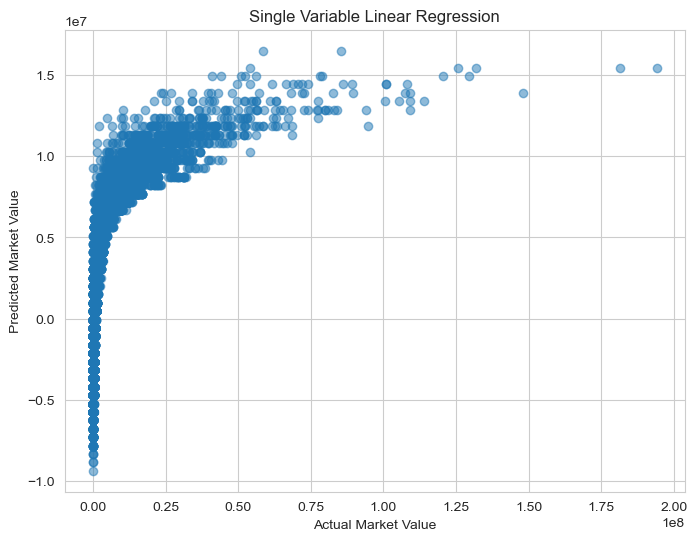

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Market Value")

plt.ylabel("Predicted Market Value")

plt.title("Single Variable Linear Regression")

plt.show()

### Interpretation

The simple linear regression model uses only Overall Rating to predict player market value.

The evaluation metrics provide a baseline against which more advanced models can be compared. Although Overall Rating is expected to be an important predictor, player valuation is influenced by many additional factors such as age, potential, wages, reputation, and technical ability.

In [38]:
#Multiple linear regression

features = [
    'overall',
    'potential',
    'age',
    'wage_eur',
    'height_cm',
    'weight_kg',
    'pace',
    'shooting',
    'passing',
    'dribbling',
    'defending',
    'physic',
    'international_reputation',
    'skill_moves',
    'weak_foot'
]

X = players[features]

y = players['value_eur']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
multi_linear = LinearRegression()

multi_linear.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](15,)","[ 208499.92, -14463.64,-247408.47,...,2676300.5 , 581185.84, 58589.75]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](15,)","['overall','potential','age',...,'international_reputation','skill_moves', 'weak_foot']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-9.152e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,15


In [41]:
y_pred_multi = multi_linear.predict(X_test)

In [42]:
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))

mae_multi = mean_absolute_error(y_test, y_pred_multi)

r2_multi = r2_score(y_test, y_pred_multi)

print("RMSE:", rmse_multi)
print("MAE:", mae_multi)
print("R²:", r2_multi)

RMSE: 3732612.395931428
MAE: 1609900.152273808
R²: 0.6499530565994325


### Model Comparison

The multiple linear regression model outperformed the single-variable model. While Overall Rating alone explains almost 32% of the variation in player market value, combining demographic, physical, and technical attributes increased the explained variation to approximately 65%.

This improvement demonstrates that player valuation is influenced by multiple interacting factors rather than a single characteristic.

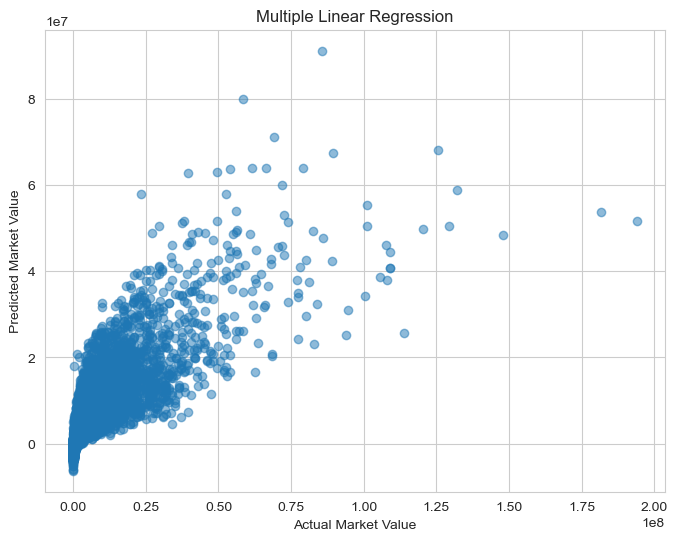

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_multi, alpha=0.5)

plt.xlabel("Actual Market Value")

plt.ylabel("Predicted Market Value")

plt.title("Multiple Linear Regression")

plt.show()

### Interpretation

Compared with the single-variable model, the multiple linear regression model incorporates demographic, physical, and technical player attributes.

An improvement in RMSE, MAE, or R² would indicate that combining multiple predictors provides a more accurate estimate of player market value than relying solely on Overall Rating.

# Polynomial Regression

Polynomial Regression extends Linear Regression by introducing polynomial terms. This allows the model to capture non-linear relationships between player attributes and market value that cannot be represented by a straight line.

In [44]:
X = players[['overall']]

y = players['value_eur']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [46]:
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('linear', LinearRegression())
])

poly_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('poly', ...), ('linear', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](1,)",['overall']
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [47]:
y_pred_poly = poly_model.predict(X_test)

In [48]:
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

mae_poly = mean_absolute_error(y_test, y_pred_poly)

r2_poly = r2_score(y_test, y_pred_poly)

print("RMSE:", rmse_poly)
print("MAE:", mae_poly)
print("R²:", r2_poly)

RMSE: 3758453.877799895
MAE: 1917104.2629639555
R²: 0.6450894150994909


### Interpretation

The Polynomial Regression model produced performance similar to the Multiple Linear Regression model but did not provide a meaningful improvement. This suggests that introducing a non-linear relationship using Overall Rating alone is insufficient to capture the complexity of player market valuation.

These results indicate that player value is influenced by multiple interacting characteristics rather than by a simple non-linear relationship with Overall Rating.

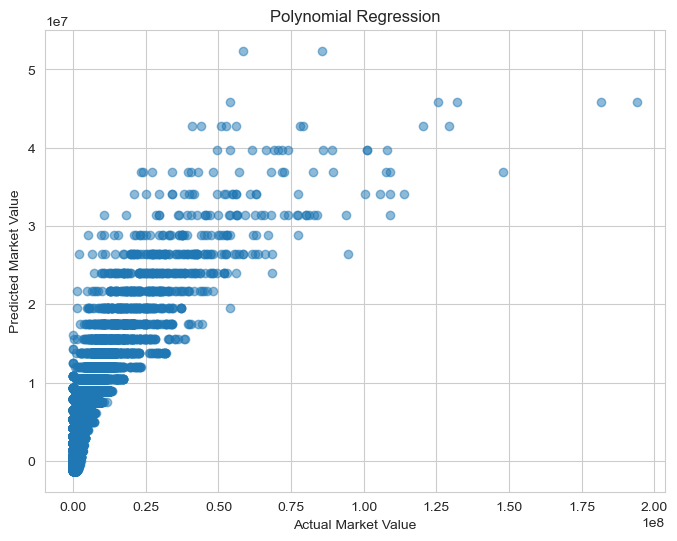

In [49]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_poly, alpha=0.5)

plt.xlabel("Actual Market Value")

plt.ylabel("Predicted Market Value")

plt.title("Polynomial Regression")

plt.show()

# Ridge Regression

Ridge Regression is a regularized version of Linear Regression that helps reduce overfitting by penalizing excessively large model coefficients.

The optimal regularization parameter (alpha) will be selected using GridSearchCV.

In [52]:
features = [
    'overall',
    'potential',
    'age',
    'wage_eur',
    'height_cm',
    'weight_kg',
    'pace',
    'shooting',
    'passing',
    'dribbling',
    'defending',
    'physic',
    'international_reputation',
    'skill_moves',
    'weak_foot'
]

X = players[features]

y = players['value_eur']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [54]:
ridge = Ridge()

In [55]:
parameters = {
    'alpha': [0.01, 0.1, 1, 10, 100, 1000]
}

In [56]:
ridge_cv = GridSearchCV(
    ridge,
    parameters,
    cv=5,
    scoring='r2'
)

ridge_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding mor

In [57]:
print("Best Alpha:", ridge_cv.best_params_)

Best Alpha: {'alpha': 10}


In [59]:
best_ridge = ridge_cv.best_estimator_

In [60]:
y_pred_ridge = best_ridge.predict(X_test)

In [61]:
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

r2_ridge = r2_score(y_test, y_pred_ridge)

print("RMSE:", rmse_ridge)
print("MAE:", mae_ridge)
print("R²:", r2_ridge)

RMSE: 3732613.4854432046
MAE: 1609871.3866966388
R²: 0.6499528522490834


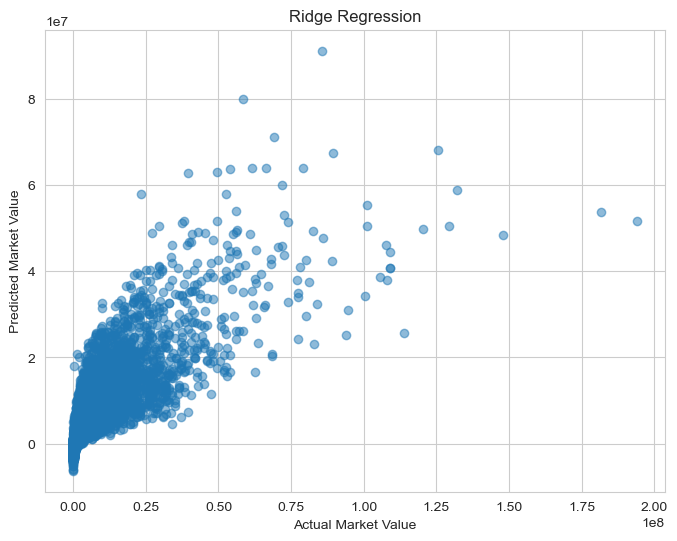

In [62]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_ridge, alpha=0.5)

plt.xlabel("Actual Market Value")

plt.ylabel("Predicted Market Value")

plt.title("Ridge Regression")

plt.show()

## Model Comparison

In [63]:
results = pd.DataFrame({
    "Model": [
        "Single Linear Regression",
        "Multiple Linear Regression",
        "Polynomial Regression",
        "Ridge Regression"
    ],

    "RMSE": [
        rmse,
        rmse_multi,
        rmse_poly,
        rmse_ridge
    ],

    "MAE": [
        mae,
        mae_multi,
        mae_poly,
        mae_ridge
    ],

    "R²": [
        r2,
        r2_multi,
        r2_poly,
        r2_ridge
    ]
})

results

,Model,RMSE,MAE,R²
0,Single Linear Regression,5.202102e+06,2.527343e+06,0.320079
1,Multiple Linear Regression,3.732612e+06,1.609900e+06,0.649953
2,Polynomial Regression,3.758454e+06,1.917104e+06,0.645089
3,Ridge Regression,3.732613e+06,1.609871e+06,0.649953


In [64]:
results.sort_values(
    by="R²",
    ascending=False
)

,Model,RMSE,MAE,R²
1,Multiple Linear Regression,3.732612e+06,1.609900e+06,0.649953
3,Ridge Regression,3.732613e+06,1.609871e+06,0.649953
2,Polynomial Regression,3.758454e+06,1.917104e+06,0.645089
0,Single Linear Regression,5.202102e+06,2.527343e+06,0.320079


In [65]:
results.style\
.background_gradient(cmap="Greens")\
.format({
    "RMSE":"{:,.0f}",
    "MAE":"{:,.0f}",
    "R²":"{:.3f}"
})

,Model,RMSE,MAE,R²
0,Single Linear Regression,"5,202,102","2,527,343",0.320
1,Multiple Linear Regression,"3,732,612","1,609,900",0.650
2,Polynomial Regression,"3,758,454","1,917,104",0.645
3,Ridge Regression,"3,732,613","1,609,871",0.650


## Model Performance Comparison

Four regression models were developed to predict football player market value.

The Multiple Linear Regression model achieved the best overall performance, producing the lowest prediction error and the highest coefficient of determination (R²).

Although Ridge Regression produced nearly identical results, regularization did not significantly improve predictive performance. This suggests that the selected predictor variables were already providing a stable model with limited overfitting.

Polynomial Regression also performed well but did not outperform the multiple linear model, indicating that introducing non-linear terms using a single predictor did not substantially improve prediction accuracy.

Overall, Multiple Linear Regression was selected as the best-performing model for this dataset.

# Hyperparameter Tuning

GridSearchCV was used to determine the optimal regularization strength (alpha) for the Ridge Regression model.

Several alpha values were evaluated using five-fold cross-validation. The model with the highest average validation R² score was selected as the final Ridge Regression model.

Although Ridge Regression performed similarly to Multiple Linear Regression, regularization provides additional protection against overfitting and may improve generalization on unseen data.

# Conclusion

The objective of this project was to predict football player market value using demographic, physical, and technical player attributes from the EA SPORTS FC 24 dataset.

Following data cleaning and exploratory data analysis, four regression models were developed and evaluated.

Among the evaluated models, Multiple Linear Regression achieved the best overall predictive performance, explaining approximately 65% of the variation in player market value. Polynomial Regression and Ridge Regression produced similar results but did not significantly outperform the multiple linear model.

The analysis also demonstrated that player market value is influenced by several interacting characteristics rather than a single attribute such as Overall Rating.

Future work could improve model performance by incorporating additional variables such as contract duration, player injuries, transfer history, league competitiveness, and team financial strength.

# References

1. Stefano Leone. (2024). *EA SPORTS FC 24 Complete Player Dataset*. Kaggle.
https://www.kaggle.com/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset

2. OpenAI. (2026). *ChatGPT (GPT-5.5)*. https://chat.openai.com/
Used to assist with project planning, exploratory data analysis, code refinement, model interpretation, and documentation.

3. Scikit-learn Developers. *Scikit-learn Documentation*.
https://scikit-learn.org/stable/

4. Pandas Development Team. *Pandas Documentation*.
https://pandas.pydata.org/docs/

5. Matplotlib Development Team. *Matplotlib Documentation*.
https://matplotlib.org/

6. Seaborn Development Team. *Seaborn Documentation*.
https://seaborn.pydata.org/